In [17]:
# infer_parameters.py
from __future__ import annotations
from copy import deepcopy
from pathlib import Path
from typing import Sequence, Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
from scipy.optimize import least_squares
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt 

# utilities
from bioprocess_utils import *   

In [18]:
inputs = load_model_inputs("./inputs/inputs.json") # load seed inputs
prms_to_infer = ("mu_max","K_subs","K_L_a")
csv_path="./simulated_dataset/pputida_fedbatch_v1.wide.csv"  # dataset generated from "true" inputs, not the noisy inputs
observables = ("Biomass","Sub")
# updating the initial states of the observables
df = load_synthetic_dataset(csv_path)[0]
mean_observables = {obs_i:np.array([np.mean([df[obs_i][it+6*iexp] for iexp in np.unique(df["experiment"])]) for it in range(0,6)]) for obs_i in observables}
# setting up the initials values of the model inputs
[inputs["initials"][obs]["values"].__setitem__(0, mean_observables[obs][0]) for obs in observables]
display(mean_observables)

{'Biomass': array([0.04837234, 0.0608373 , 0.09046628, 0.17528061, 0.18931802,
        0.17260969]),
 'Sub': array([1.36125293e-01, 1.19124929e-01, 8.84835253e-02, 1.29038447e-03,
        2.80952427e-11, 7.34699838e-12])}

In [19]:

# Fit μmax, Ks, KLa from BIOMASS across all experiments in the CSV
report = fit_parameters(
    csv_path=csv_path,         
    inputs = inputs,
    observables=observables,
    param_names=prms_to_infer,
    initial_names=(),           # to also infer Biomass0: initial_names=("Biomass",)
    experiment_ids=None,        # None -> use all experiments; or pass e.g. [0]
    bounds =(np.array([0.0,0.0,0.0]),np.array([0.1,1.0,10.0])),              # None -> auto ±10× around seeds def: None 
    x0=None,                    # None -> seeds from inputs.json
    verbose=2,
)
print("\n=== Fit summary ===")
for name, val in zip(report["theta_names"], report["theta_opt"]):
    print(f"{name:10s} = {val:.6g}")
print("success:", report["success"], "| cost:", report["cost"])

(array([0., 0., 0.]), array([ 0.1,  1. , 10. ]))
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.4225e+01                                    8.22e+00    
       1             14         8.4225e+01      0.00e+00       0.00e+00       8.22e+00    
`xtol` termination condition is satisfied.
Function evaluations 14, initial cost 8.4225e+01, final cost 8.4225e+01, first-order optimality 8.22e+00.

=== Fit summary ===
mu_max     = 0.0104715
K_subs     = 0.0600137
K_L_a      = 5.44547
success: True | cost: 84.22514488448547


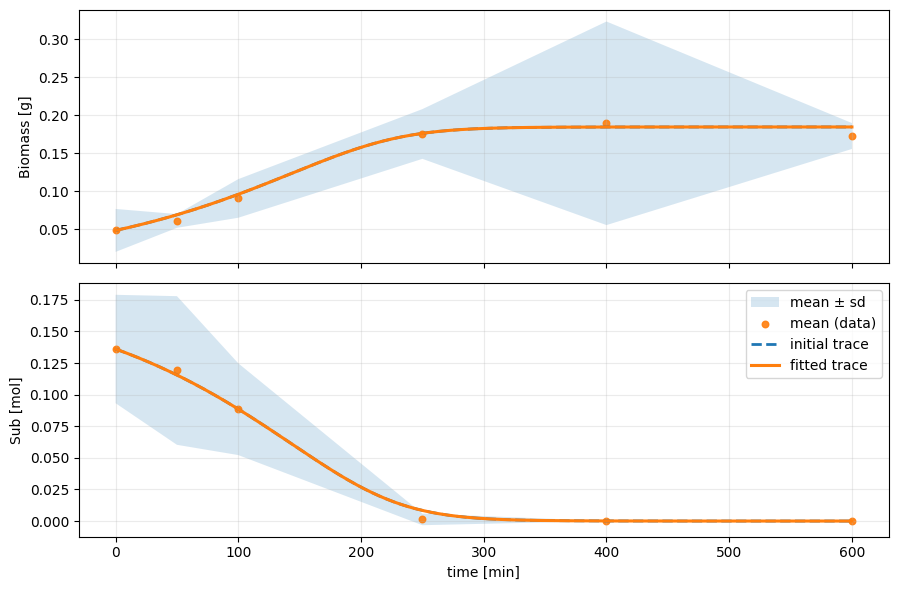

In [20]:
fitted_inputs = report["fitted_inputs"]

fig, axes = plot_dataset_with_traces(
    csv_path=csv_path,
    inputs_init=inputs,
    inputs_fit=fitted_inputs,
    observables=observables,      
    envelope="std",)

In [21]:
# saved the current optimal inputs
save_model_inputs(fitted_inputs,out_dir="./inputs")

{'json': 'inputs/inputs.json', 'readme': 'inputs/inputs.README.txt'}